In [1]:
import argparse
import logging
from pathlib import Path
from time import time
import xarray as xr

from aislens.config import config
from aislens.dataprep import detrend_with_breakpoints_vectorized, detrend_with_breakpoints_ts
from aislens.utils import setup_logging

logger = logging.getLogger(__name__)

/Users/smurugan9/research/aislens/AISLENS/src/aislens/geospatial.py:1: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [4]:
ds = xr.open_dataset("/Users/smurugan9/research/aislens/AISLENS/data/MALI/ENSEMBLES/ISMIP6/forcing-trends-ts/floatingBasalMassBalApplied_expAE05_Trend_2015-2300_ts.nc")

In [5]:
ds[config.MALI_FLOATINGBMB_VAR] = (ds[config.MALI_FLOATINGBMB_VAR].isel(Time=0) - ds[config.MALI_FLOATINGBMB_VAR])
    

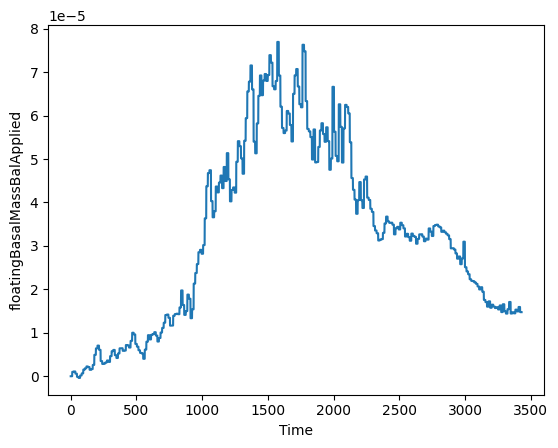

In [12]:
ds[config.MALI_FLOATINGBMB_VAR].plot()

In [ ]:
detrended_data = detrend_with_breakpoints_vectorized(ds[config.MALI_FLOATINGBMB_VAR], dim="Time", deg=1, model="rbf", penalty=10)

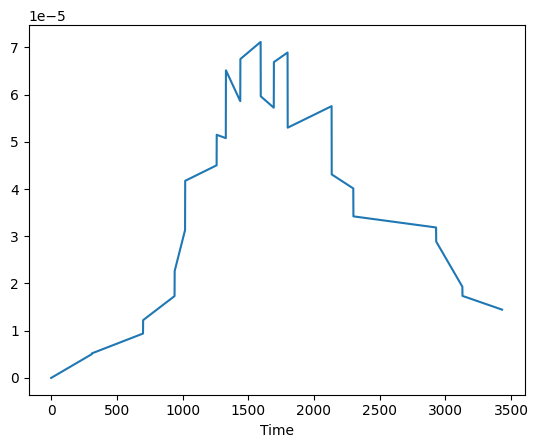

In [11]:
trend = ds[config.MALI_FLOATINGBMB_VAR] - detrended_data
trend.plot()

In [ ]:
def detrend_forcing(forcing_file_path, output_path, method='vectorized'):
    """Detrend forcing data using breakpoint detection."""
    logger.info(f"Loading {forcing_file_path}...")
    ds = xr.open_dataset(forcing_file_path)
    ds[config.MALI_FLOATINGBMB_VAR] = (ds[config.MALI_FLOATINGBMB_VAR].isel(Time=0) - 
                                        ds[config.MALI_FLOATINGBMB_VAR])
    
    if method == 'vectorized':
        logger.info("Detrending (vectorized - all spatial points)...")
        detrended_data = detrend_with_breakpoints_vectorized(
            ds[config.MALI_FLOATINGBMB_VAR], dim="Time", deg=1, model="rbf", penalty=10
        )
    else:
        logger.info("Detrending (time series - spatial mean)...")
        spatial_dims = [dim for dim in ds[config.MALI_FLOATINGBMB_VAR].dims if dim != 'Time']
        spatial_mean_ts = ds[config.MALI_FLOATINGBMB_VAR].mean(dim=spatial_dims)
        detrended_data = detrend_with_breakpoints_ts(
            spatial_mean_ts, dim="Time", deg=1, model="rbf", penalty=10
        )
    
    trend = (ds - detrended_data.to_dataset(name=config.MALI_FLOATINGBMB_VAR))
    trend = trend.rename({config.MALI_FLOATINGBMB_VAR: config.AISLENS_FLOATINGBMB_VAR})
    
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    trend.to_netcdf(output_path)
    logger.info(f"Trend saved as {output_path}")
